# Glasses2Car — Analysis of the Case Study

This notebook contains the implementation of the artifact analysis generated from a real-world case study.

**Data sources (folder `../data`):**

| File | Origin | Contents |
|---|---|---|
| `smartglass_metrics_trip{1,2}.csv` | iOS app (one row per voice interaction) | timestamps and lat/long at send/receive, per-stage pipeline timings, iPhone and glasses resources, spoken text, raw API payload |
| `telemetry_trip{1,2}.csv` | App2Car vehicular collector (OBD-II + phone GPS) | full vehicle route: position, speed, RPM, etc., ~1 Hz |

**Artifacts produced (as used in the paper):**
- **Table I** — latency per request type, median [IQR] (Section 4);
- **Fig. 3** — `latency_breakdown.png`, median stage breakdown (Section 4);
- **Fig. 4** — `request_map.png` + per-trip interactive maps (Section 3);
- The communication-overhead and resource numbers quoted in Section V of the
  paper (Sections 5–6 here).


## 1. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
# Article-ready typography
plt.rcParams.update({
    "axes.titlesize": 16, "axes.labelsize": 16,
    "xtick.labelsize": 16, "ytick.labelsize": 16,
    "legend.fontsize": 16,
})

DATA = "../data"
INTENT_LABEL = {
    "driving_behavior": "How am I driving?",
    "emissions": "How am I emitting?",
    "trip_summary": "Trip summary",
}
# Saturated tones (map markers, edges) and pastel fills (bars)
INTENT_COLOR = {
    "driving_behavior": "#37AFD4",
    "emissions": "#2E9E6B",
    "trip_summary": "#D4762E",
}
INTENT_PASTEL = {
    "driving_behavior": "#9BD7EA",
    "emissions": "#96CEB5",
    "trip_summary": "#E9BA96",
}

## 2. Loading and preparing the data

Two **timezone** caveats, discovered while inspecting the data: the app
metrics are in **UTC** (`Z` suffix) and the vehicular telemetry is in
**Natal local time (UTC−3)**, with no suffix. Everything is converted to UTC
so the two sources can be joined.

In [2]:
def load_metrics(trip_id):
    df = pd.read_csv(f"{DATA}/smartglass_metrics_trip{trip_id}.csv")
    df["trip"] = trip_id
    for col in ["t_wake", "t_command", "t_request_sent", "t_response_received", "t_tts_requested"]:
        df[col] = pd.to_datetime(df[col], utc=True, format="mixed")
    return df

def load_telemetry(trip_id):
    df = pd.read_csv(f"{DATA}/telemetry_trip{trip_id}.csv")
    df["trip"] = trip_id
    # Natal local time (UTC-3, no DST) -> UTC
    df["time_sensor"] = (pd.to_datetime(df["time_sensor"], format="mixed")
                           .dt.tz_localize("America/Fortaleza")
                           .dt.tz_convert("UTC"))
    return df.sort_values("time_sensor")

met = pd.concat([load_metrics(1), load_metrics(2)], ignore_index=True)
tel = pd.concat([load_telemetry(1), load_telemetry(2)], ignore_index=True)

for col in ["asr_ms", "api_ms", "format_ms", "tts_synthesis_delay_ms",
            "cpu_pct", "mem_mb", "battery_pct",
            "lat_sent", "lon_sent", "lat_recv", "lon_recv"]:
    met[col] = pd.to_numeric(met[col], errors="coerce")

# Paper metrics: TTFA (from command recognition to first audio) and the
# response-preparation overhead (formatting + TTS start delay)
met["ttfa_ms"] = met[["api_ms", "format_ms", "tts_synthesis_delay_ms"]].sum(axis=1)
met["prep_ms"] = met["format_ms"] + met["tts_synthesis_delay_ms"]
met["question"] = met["intent"].map(INTENT_LABEL)

print(f"Voice interactions: {len(met)}  (trip 1: {(met.trip == 1).sum()}, trip 2: {(met.trip == 2).sum()})")
print(f"Vehicular telemetry samples: {len(tel)}")
met[["trip", "interaction_id", "question", "endpoint", "asr_ms", "api_ms", "ttfa_ms"]].round(0).head(6)

Voice interactions: 22  (trip 1: 11, trip 2: 11)
Vehicular telemetry samples: 1312


,trip,interaction_id,question,endpoint,asr_ms,api_ms,ttfa_ms
0,1,1,How am I driving?,smart-glass/driver-behavior,2905.0,346.0,354.0
1,1,2,How am I driving?,smart-glass/driver-behavior,2168.0,376.0,382.0
2,1,3,How am I emitting?,smart-glass/emissions,2160.0,383.0,389.0
3,1,4,How am I driving?,smart-glass/driver-behavior,2056.0,466.0,474.0
4,1,5,How am I emitting?,smart-glass/emissions,2402.0,365.0,374.0
5,1,6,How am I driving?,smart-glass/driver-behavior,2203.0,433.0,440.0


### 2.1 Data-quality check: request positions

In [3]:
print("Distinct positions recorded by the app, per trip:")
print(met.groupby("trip")[["lat_sent", "lon_sent"]].nunique().to_string())

tel_pos = tel[["time_sensor", "latitude", "longitude", "speed", "trip"]] \
    .dropna(subset=["latitude", "longitude"]).sort_values("time_sensor")

def reconstruct(df, time_col, suffix):
    rec = pd.merge_asof(
        df.sort_values(time_col), tel_pos, left_on=time_col,
        right_on="time_sensor", by="trip", direction="nearest",
        tolerance=pd.Timedelta("5s"))
    return rec.rename(columns={"latitude": f"lat_{suffix}", "longitude": f"lon_{suffix}",
                               "speed": f"speed_{suffix}"}) \
              .drop(columns=["time_sensor"])

met = reconstruct(met, "t_request_sent", "req")
met = reconstruct(met, "t_response_received", "resp")
met = met.sort_values(["trip", "interaction_id"]).reset_index(drop=True)

print("\nDistinct reconstructed positions per trip:")
print(met.groupby("trip")[["lat_req", "lon_req"]].nunique().to_string())

Distinct positions recorded by the app, per trip:
      lat_sent  lon_sent
trip                    
1            2         1
2            2         2

Distinct reconstructed positions per trip:
      lat_req  lon_req
trip                  
1          11       11
2          11       11


## 3. Route map (paper Fig. 4)

Rendered over CartoDB Positron tiles (© OpenStreetMap contributors, © CARTO).
Each **circle** is the reconstructed point where a request was **sent**; the
**X** is where the response was **received**. Labels within ~30 m of each
other (e.g., interactions 1 and 11, since the laps start and end at the same
spot) receive distinct offsets to avoid overlap.

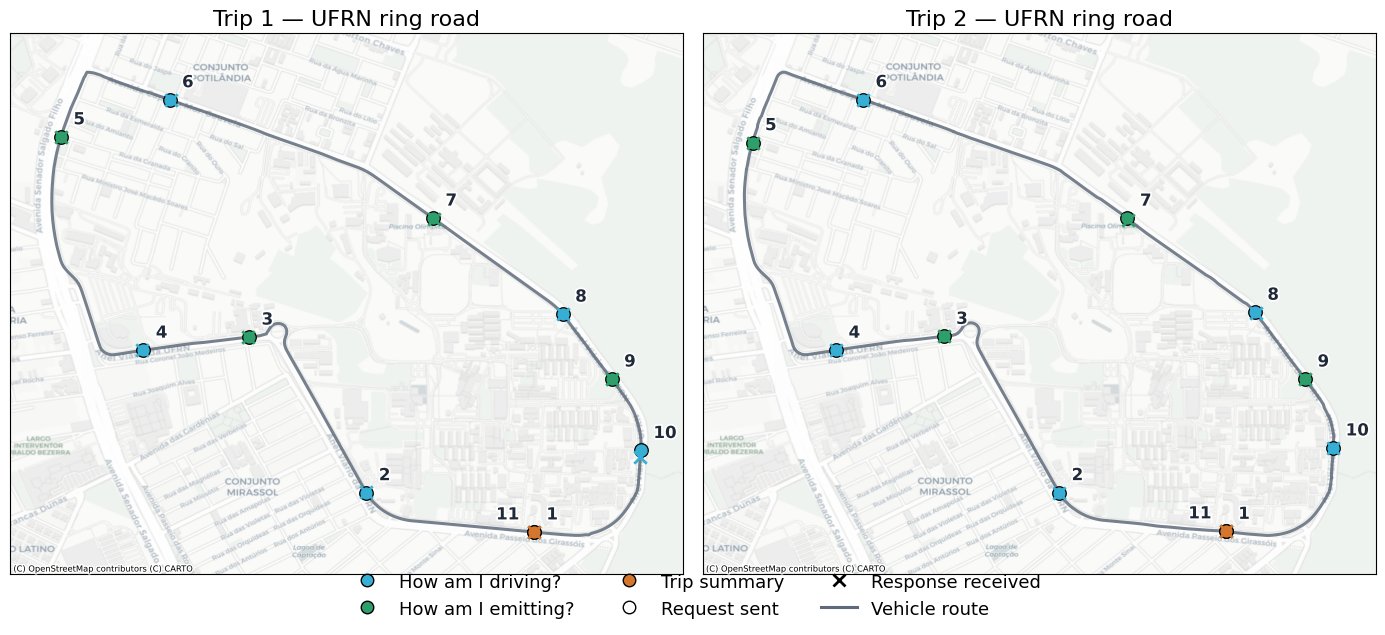

In [4]:
import contextily as ctx
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

# Offset slots (in points) cycled inside each cluster of nearby labels
LABEL_SLOTS = [(9, 9), (-27, 9), (9, -21), (-27, -21), (22, -6), (-40, -6)]

def label_offsets(points, threshold_deg=3e-4):
    """Assigns an offset slot per point; points closer than ~30 m share a
    cluster and take successive slots so their labels do not overlap."""
    offsets, clusters = {}, []
    for idx, row in points.iterrows():
        placed = False
        for cluster in clusters:
            ref = points.loc[cluster[0]]
            if (abs(row.lat_req - ref.lat_req) < threshold_deg
                    and abs(row.lon_req - ref.lon_req) < threshold_deg):
                cluster.append(idx)
                offsets[idx] = LABEL_SLOTS[(len(cluster) - 1) % len(LABEL_SLOTS)]
                placed = True
                break
        if not placed:
            clusters.append([idx])
            offsets[idx] = LABEL_SLOTS[0]
    return offsets

fig, axes = plt.subplots(1, 2, figsize=(14, 6.4))

for ax, trip_id in zip(axes, [1, 2]):
    route = tel[tel.trip == trip_id]
    points = met[(met.trip == trip_id) & met.lat_req.notna()]
    ax.plot(route["longitude"], route["latitude"], color="#5F6B7A", lw=2.2,
            alpha=0.85, zorder=2)
    for intent, group in points.groupby("intent"):
        ax.scatter(group["lon_req"], group["lat_req"], s=95, zorder=4,
                   color=INTENT_COLOR[intent], edgecolor="black", lw=0.9)
        ax.scatter(group["lon_resp"], group["lat_resp"], s=80, zorder=4,
                   color=INTENT_COLOR[intent], marker="x", lw=2)
    offsets = label_offsets(points)
    for idx, r in points.iterrows():
        ax.annotate(int(r.interaction_id), (r.lon_req, r.lat_req),
                    textcoords="offset points", xytext=offsets[idx],
                    fontsize=12, fontweight="bold", color="#1F2937", zorder=5,
                    path_effects=[pe.withStroke(linewidth=2.6, foreground="white")])
    pad = 0.0012
    ax.set_xlim(route["longitude"].min() - pad, route["longitude"].max() + pad)
    ax.set_ylim(route["latitude"].min() - pad, route["latitude"].max() + pad)
    ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.CartoDB.Positron,
                    attribution_size=6)
    ax.set_title(f"Trip {trip_id} — UFRN ring road")
    ax.set_xticks([]); ax.set_yticks([])
    ax.grid(False)

legend_handles = [
    Line2D([], [], marker="o", ls="", mfc=INTENT_COLOR[i], mec="black", ms=9,
           label=INTENT_LABEL[i]) for i in INTENT_LABEL
] + [
    Line2D([], [], marker="o", ls="", mfc="white", mec="black", ms=9, label="Request sent"),
    Line2D([], [], marker="x", ls="", color="black", ms=9, mew=2, label="Response received"),
    Line2D([], [], color="#5F6B7A", lw=2.2, label="Vehicle route"),
]
plt.tight_layout(rect=[0, 0.07, 1, 1])
fig.legend(handles=legend_handles, loc="lower center", ncol=3, fontsize=13,
           frameon=False, bbox_to_anchor=(0.5, 0.0))
plt.savefig("request_map.png", dpi=200, bbox_inches="tight")
plt.show()

### Interactive per-trip maps

Browsable version of Fig. 4 (screenshot source): interaction numbers, sent
(●) / received (✕) markers and an embedded legend. Writes
`interactive_map_trip1.html` and `interactive_map_trip2.html`; the popup of
each point shows the question and its latencies.

In [5]:
import folium
from folium.features import DivIcon

LEGEND_HTML = """
<div style="position: fixed; bottom: 20px; left: 20px; z-index: 9999;
            background: rgba(255,255,255,0.96); border: 1px solid #9CA3AF;
            border-radius: 10px; padding: 12px 16px; line-height: 1.7;
            font-family: Helvetica, Arial, sans-serif; font-size: 13px;
            color: #1F2937; box-shadow: 0 1px 6px rgba(0,0,0,0.15);">
  <div><span style="display:inline-block;width:12px;height:12px;border-radius:50%;
      background:#37AFD4;border:1.5px solid #000;margin-right:7px;"></span>How am I driving?</div>
  <div><span style="display:inline-block;width:12px;height:12px;border-radius:50%;
      background:#2E9E6B;border:1.5px solid #000;margin-right:7px;"></span>How am I emitting?</div>
  <div style="margin-bottom:6px;"><span style="display:inline-block;width:12px;height:12px;
      border-radius:50%;background:#D4762E;border:1.5px solid #000;margin-right:7px;"></span>Trip summary</div>
  <div><span style="display:inline-block;width:12px;height:12px;border-radius:50%;
      background:#fff;border:1.5px solid #000;margin-right:7px;"></span>Request sent</div>
  <div><span style="font-weight:700;font-size:14px;margin-right:7px;">&#10005;</span>Response received</div>
  <div><span style="display:inline-block;width:16px;height:3px;background:#5F6B7A;
      margin-right:7px;vertical-align:middle;"></span>Vehicle route</div>
</div>
"""

for trip_id in [1, 2]:
    route = tel[tel.trip == trip_id]
    points = met[(met.trip == trip_id) & met.lat_req.notna()]
    center = [route.latitude.mean(), route.longitude.mean()]
    m = folium.Map(location=center, zoom_start=15, tiles="cartodbpositron")
    folium.PolyLine(route[["latitude", "longitude"]].values.tolist(),
                    color="#5F6B7A", weight=4, opacity=0.85).add_to(m)

    offsets = label_offsets(points)  # same declustering as the static map
    for idx, r in points.iterrows():
        popup = (f"T{trip_id}-{int(r.interaction_id)} &middot; {r.question}<br>"
                 f"API: {r.api_ms:.0f} ms &middot; TTFA: {r.ttfa_ms:.0f} ms")
        folium.map.Marker(
            [r.lat_resp, r.lon_resp],
            icon=DivIcon(icon_size=(20, 20), icon_anchor=(10, 10),
                         html=(f'<div style="font-size:17px;font-weight:700;'
                               f'color:{INTENT_COLOR[r.intent]};'
                               f'text-shadow:0 0 3px #fff,0 0 3px #fff;">&#10005;</div>'))
        ).add_to(m)
        folium.CircleMarker([r.lat_req, r.lon_req], radius=8, color="black",
                            weight=1.2, fill=True, fill_color=INTENT_COLOR[r.intent],
                            fill_opacity=1, popup=popup).add_to(m)
        dx, dy = offsets[idx]
        folium.map.Marker(
            [r.lat_req, r.lon_req],
            icon=DivIcon(icon_size=(34, 20), icon_anchor=(-dx, dy),
                         html=(f'<div style="font-size:14px;font-weight:700;color:#1F2937;'
                               f'text-shadow:0 0 3px #fff,0 0 3px #fff,0 0 4px #fff;">'
                               f'{int(r.interaction_id)}</div>'))
        ).add_to(m)

    m.get_root().html.add_child(folium.Element(LEGEND_HTML))
    m.save(f"interactive_map_trip{trip_id}.html")
    print(f"interactive_map_trip{trip_id}.html written")

m  # renders the trip-2 map inline

interactive_map_trip1.html written
interactive_map_trip2.html written


## 4. Latency (paper Table I and Fig. 3)

Convention: **median [interquartile range]** — latency distributions are
skewed with outliers (a single *How am I driving?* API event reached ~3.8 s,
an order of magnitude above that query's IQR of 394–471 ms), so mean ±
standard deviation would be misleading. For the *trip summary* (n=2) the two
individual values are reported instead of statistics.

In [6]:
def med_iqr(s):
    return f"{s.median():.0f} [{s.quantile(.25):.0f}\u2013{s.quantile(.75):.0f}]"

table_1 = met.groupby("question").agg(
    n=("interaction_id", "count"),
    ASR_ms=("asr_ms", med_iqr),
    API_ms=("api_ms", med_iqr),
    TTFA_ms=("ttfa_ms", med_iqr),
)
ts_values = met.loc[met.intent == "trip_summary", ["asr_ms", "api_ms", "ttfa_ms"]].round(0)
print("Trip summary (n=2) — reported as the two individual values:")
print(ts_values.to_string(index=False))
outlier = met.loc[met.intent == "driving_behavior", "api_ms"].max()
print(f"\nSingle higher-latency driving event: {outlier:.0f} ms")
table_1

Trip summary (n=2) — reported as the two individual values:
 asr_ms  api_ms  ttfa_ms
 1704.0  6508.0   6514.0
 1689.0  8317.0   8327.0

Single higher-latency driving event: 3802 ms


,n,ASR_ms,API_ms,TTFA_ms
question,,,,
How am I driving?,12,2077 [2030–2242],434 [394–471],440 [399–478]
How am I emitting?,8,2173 [2141–2370],385 [362–528],390 [371–536]
Trip summary,2,1696 [1693–1700],7412 [6960–7865],7421 [6967–7874]


### Fig. 3 — median stage breakdown

For each question, the stacked **medians** of the pipeline stages from
wake-word detection to response onset (Speech + ASR → API → formatting + TTS
start). The axis label says *response onset* on purpose: this quantity
includes the user's speech, so it is $t_{ASR}$ + TTFA, not the TTFA itself.

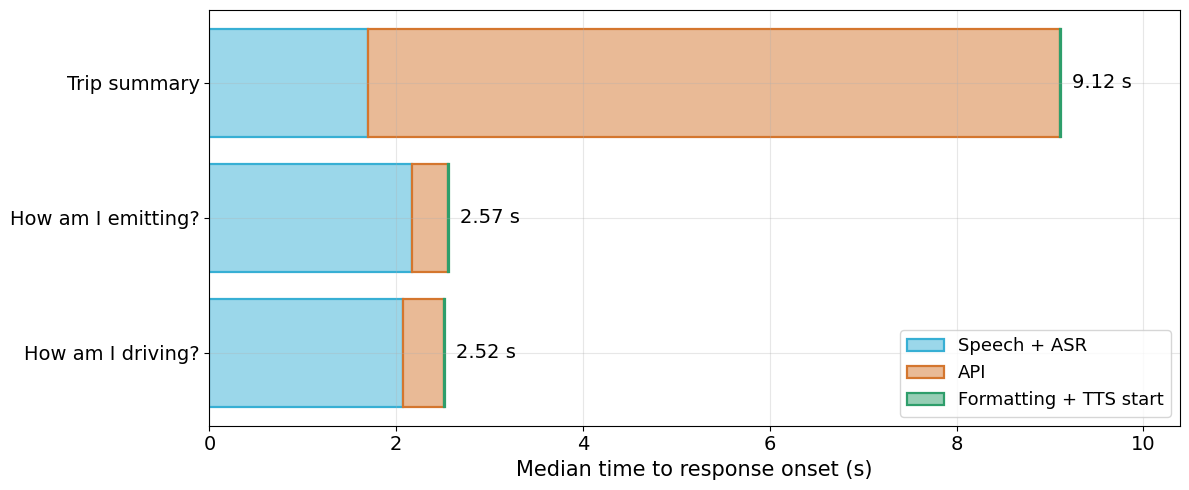

In [7]:
STAGE_ORDER = [("asr_ms", "Speech + ASR"), ("api_ms", "API"),
               ("prep_ms", "Formatting + TTS start")]
STAGE_FILL = {"asr_ms": "#9BD7EA", "api_ms": "#E9BA96", "prep_ms": "#96CEB5"}
STAGE_EDGE = {"asr_ms": "#37AFD4", "api_ms": "#D4762E", "prep_ms": "#2E9E6B"}

medians = met.groupby("question")[["asr_ms", "api_ms", "prep_ms"]].median()
medians = medians.loc[medians.sum(axis=1).sort_values(ascending=True).index]

fig, ax = plt.subplots(figsize=(12, 5))
left = np.zeros(len(medians))
for stage, label in STAGE_ORDER:
    vals = medians[stage].to_numpy() / 1000
    ax.barh(medians.index, vals, left=left, label=label,
            color=STAGE_FILL[stage], edgecolor=STAGE_EDGE[stage], linewidth=1.6)
    left += vals
for i, total in enumerate(left):
    ax.text(total + 0.12, i, f"{total:.2f} s", va="center", fontsize=14)
ax.set_xlabel("Median time to response onset (s)")
ax.set_xlim(0, left.max() * 1.14)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("latency_breakdown.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Communication overhead

Numbers quoted in Section V of the paper. Response sizes are **measured**
from the logged raw payloads; request sizes are **estimated** (URL + query +
body + typical URLSession/Authorization headers). The App2Car telemetry
stream volume, estimated from the serialized payload of the collected
samples, provides the comparison baseline.

In [8]:
HDR_BASE = 350       # request line + typical URLSession Host/Accept/User-Agent
HDR_AUTH = 260       # typical "Authorization: Bearer <token>" for this API

def request_bytes(r):
    if r.endpoint == "smart-glass/driver-behavior":
        query = f"window_seconds=120&latitude={r.lat_sent}&longitude={r.lon_sent}"
        url = f"http://testes.conect2ai.dca.ufrn.br:8000/v1/smart-glass/driver-behavior/?{query}"
        body = 0
    elif r.endpoint == "smart-glass/emissions":
        query = f"latitude={r.lat_sent}&longitude={r.lon_sent}"
        url = f"http://testes.conect2ai.dca.ufrn.br:8000/v1/smart-glass/emissions/?{query}"
        body = 0
    else:  # trip/summary (POST)
        url = "http://testes.conect2ai.dca.ufrn.br:8000/v1/smart-glass/trip/summary"
        body = len(f'{{"send_email": false, "latitude": {r.lat_sent}, "longitude": {r.lon_sent}}}')
    return len(url.encode()) + body + HDR_BASE + HDR_AUTH

met["request_bytes_est"] = met.apply(request_bytes, axis=1)
met["response_bytes"] = met["api_raw_response"].fillna("").str.encode("utf-8").str.len()

sent_kib = met.request_bytes_est.sum() / 1024
recv_kib = met.response_bytes.sum() / 1024
print(f"Estimated outgoing traffic (22 requests): ~{sent_kib:.1f} KiB")
print(f"Measured response payloads: {recv_kib:.1f} KiB")

tel_rows, tel_bytes = 0, 0
for t in [1, 2]:
    with open(f"{DATA}/telemetry_trip{t}.csv") as f:
        rows = f.readlines()[1:]
    tel_rows += len(rows)
    tel_bytes += sum(len(l.encode()) for l in rows)
frac = (met.request_bytes_est.sum() + met.response_bytes.sum()) / tel_bytes * 100
print(f"App2Car stream in the same sessions: {tel_rows} samples, "
      f"~{tel_bytes/1024:.0f} KiB ({tel_bytes/tel_rows:.0f} B/sample)")
print(f"Interaction traffic ({sent_kib + recv_kib:.1f} KiB) \u2248 {frac:.0f}% of the telemetry stream")

Estimated outgoing traffic (22 requests): ~16.1 KiB
Measured response payloads: 8.0 KiB
App2Car stream in the same sessions: 1312 samples, ~475 KiB (371 B/sample)
Interaction traffic (24.1 KiB) ≈ 5% of the telemetry stream


## 6. Smartphone resource footprint

Numbers quoted in Section V of the paper. The Meta Wearables Device Access
Toolkit exposes no CPU/memory/battery measurements for the glasses, so these
figures refer to the Glasses2Car app on the iPhone.

In [9]:
print(f"Median CPU utilization: {met.cpu_pct.median():.1f}% of one core")
print(f"Median physical memory footprint: {met.mem_mb.median():.0f} MB")
print("iPhone thermal states:", met["thermal"].value_counts().to_dict())
print(f"Battery at interaction instants: constant at {met.battery_pct.median():.0f}% "
      "(device not connected to power)")

Median CPU utilization: 0.7% of one core
Median physical memory footprint: 29 MB
iPhone thermal states: {'nominal': 22}
Battery at interaction instants: constant at 100% (device not connected to power)


## 7. Summary

1. Sub-second response onset for the in-drive queries: median TTFA of
   **440 ms** (driving behavior) and **390 ms** (emissions); the trip summary
   took 6.5 s / 8.3 s, dominated by session aggregation and trip finalization
   on the server (RQ1/RQ2);
2. The interaction traffic (~24.1 KiB across 22 requests) is roughly **5%**
   of the ~475 KiB telemetry stream transmitted in parallel by App2Car (RQ3);
3. Smartphone footprint: median **0.7% CPU**, **29 MB** memory, *nominal*
   thermal state, and no measurable battery drain at 1% resolution (RQ3);
4. Instrumentation limitations documented in the paper: glasses resources not
   exposed by the SDK, request sizes estimated, and request positions
   reconstructed from the vehicle telemetry.